In [1]:
import pandas as pd

fish=pd.read_csv('http://bit.ly/fish_csv_data')
fish.head()

,Species,Weight,Length,Diagonal,Height,Width
0,Bream,242.0,25.4,30.0,11.5200,4.0200
1,Bream,290.0,26.3,31.2,12.4800,4.3056
2,Bream,340.0,26.5,31.1,12.3778,4.6961
3,Bream,363.0,29.0,33.5,12.7300,4.4555
4,Bream,430.0,29.0,34.0,12.4440,5.1340


In [2]:
print(pd.unique(fish['Species']))
fish_input=fish[['Weight','Length','Diagonal','Height','Width']]
fish_input.head()

['Bream' 'Roach' 'Whitefish' 'Parkki' 'Perch' 'Pike' 'Smelt']


,Weight,Length,Diagonal,Height,Width
0,242.0,25.4,30.0,11.5200,4.0200
1,290.0,26.3,31.2,12.4800,4.3056
2,340.0,26.5,31.1,12.3778,4.6961
3,363.0,29.0,33.5,12.7300,4.4555
4,430.0,29.0,34.0,12.4440,5.1340


In [3]:
fish_target=fish['Species']

from sklearn.model_selection import train_test_split
train_input,test_input,train_target,test_target=train_test_split(fish_input,fish_target, random_state=42)

In [4]:
from sklearn.preprocessing import StandardScaler
ss=StandardScaler()
ss.fit(train_input)
train_scaled=ss.transform(train_input)
test_scaled=ss.transform(test_input)

In [5]:
from sklearn.neighbors import KNeighborsClassifier
kn=KNeighborsClassifier(n_neighbors=3)
kn.fit(train_scaled,train_target)
print(kn.score(train_scaled,train_target))
print(kn.score(test_scaled, test_target))

0.8907563025210085
0.85


In [6]:
print(kn.classes_)
print(kn.predict(test_scaled[:5]))

import numpy as np
proba=kn.predict_proba(test_scaled[:5])
print(np.round(proba,decimals=4))

['Bream' 'Parkki' 'Perch' 'Pike' 'Roach' 'Smelt' 'Whitefish']
['Perch' 'Smelt' 'Pike' 'Perch' 'Perch']
[[0.     0.     1.     0.     0.     0.     0.    ]
 [0.     0.     0.     0.     0.     1.     0.    ]
 [0.     0.     0.     1.     0.     0.     0.    ]
 [0.     0.     0.6667 0.     0.3333 0.     0.    ]
 [0.     0.     0.6667 0.     0.3333 0.     0.    ]]


In [7]:
char_arr=np.array(['A','B','C','D','E'])
print(char_arr[[True,False,True,False,False]])

['A' 'C']


In [8]:
bream_smelt_indexes=(train_target=='Bream')|(train_target=='Smelt')
train_bream_smelt=train_scaled[bream_smelt_indexes]
target_bream_smelt=train_target[bream_smelt_indexes]

In [9]:
from sklearn.linear_model import LogisticRegression
lr=LogisticRegression()
lr.fit(train_bream_smelt,target_bream_smelt)
print(lr.predict(train_bream_smelt[:5]))

['Bream' 'Smelt' 'Bream' 'Bream' 'Bream']


In [10]:
print(lr.predict_proba(train_bream_smelt[:5]))

[[0.99760007 0.00239993]
 [0.02737325 0.97262675]
 [0.99486386 0.00513614]
 [0.98585047 0.01414953]
 [0.99767419 0.00232581]]


In [11]:
print(lr.classes_)

['Bream' 'Smelt']


In [12]:
lr = LogisticRegression(C=20, max_iter=1000)
lr.fit(train_scaled, train_target)
print(lr.score(train_scaled, train_target))
print(lr.score(test_scaled, test_target))

0.9327731092436975
0.925


In [13]:
print(lr.predict(test_scaled[:5]))

['Perch' 'Smelt' 'Pike' 'Roach' 'Perch']


In [14]:
proba=lr.predict_proba(test_scaled[:5])
print(np.round(proba,decimals=3))

[[0.    0.014 0.842 0.    0.135 0.007 0.003]
 [0.    0.003 0.044 0.    0.007 0.946 0.   ]
 [0.    0.    0.034 0.934 0.015 0.016 0.   ]
 [0.011 0.034 0.305 0.006 0.567 0.    0.076]
 [0.    0.    0.904 0.002 0.089 0.002 0.001]]


In [15]:
print(lr.coef_.shape,lr.intercept_.shape)

(7, 5) (7,)


In [16]:
import pandas as pd
fish=pd.read_csv('http://bit.ly/fish_csv_data')

In [17]:
fish_input=fish[['Weight','Length','Diagonal','Height','Width']]
fish_target=fish['Species']

In [18]:
from sklearn.model_selection import train_test_split
train_input,test_input,train_target,test_target=train_test_split(fish_input,fish_target, random_state=42)

In [19]:
from sklearn.preprocessing import StandardScaler
ss=StandardScaler()
ss.fit(train_input)
train_scaled=ss.transform(train_input)
test_scaled=ss.transform(test_input)

In [21]:
from sklearn.linear_model import SGDClassifier
sc=SGDClassifier(loss='log_loss', max_iter=10, random_state=42)
sc.fit(train_scaled,train_target)
print(sc.score(train_scaled,train_target))
print(sc.score(test_scaled,test_target))

0.773109243697479
0.775


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_stochastic_gradient.py:738: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.
  warnings.warn(


In [22]:
sc.partial_fit(train_scaled,train_target)
print(sc.score(train_scaled,train_target))
print(sc.score(test_scaled,test_target))

0.7983193277310925
0.775


In [23]:
import numpy as np
sc=SGDClassifier(loss='log_loss', random_state=42)
train_score=[]
test_score=[]
classes=np.unique(train_target)

In [24]:
for _ in range(0,300):
    sc.partial_fit(train_scaled,train_target,classes=classes)
    train_score.append(sc.score(train_scaled,train_target))
    test_score.append(sc.score(test_scaled,test_target))

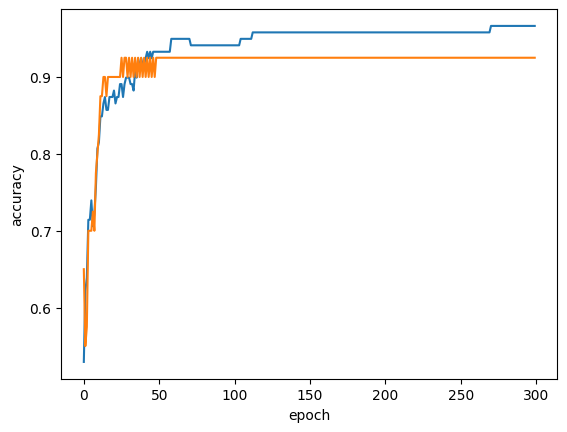

In [25]:
import matplotlib.pyplot as plt
plt.plot(train_score)
plt.plot(test_score)
plt.xlabel('epoch')
plt.ylabel('accuracy')
plt.show()

In [26]:
sc=SGDClassifier(loss='log_loss', max_iter=100, tol=None, random_state=42)
sc.fit(train_scaled, train_target)
print(sc.score(train_scaled, train_target))
print(sc.score(test_scaled, test_target))

0.957983193277311
0.925


In [27]:
# 필요한 라이브러리 import
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

In [28]:
fish = pd.read_csv('http://bit.ly/fish_csv_data')

fish.head()

,Species,Weight,Length,Diagonal,Height,Width
0,Bream,242.0,25.4,30.0,11.5200,4.0200
1,Bream,290.0,26.3,31.2,12.4800,4.3056
2,Bream,340.0,26.5,31.1,12.3778,4.6961
3,Bream,363.0,29.0,33.5,12.7300,4.4555
4,Bream,430.0,29.0,34.0,12.4440,5.1340


In [29]:
fish_input = fish[['Weight', 'Length', 'Diagonal', 'Height', 'Width']].to_numpy()

fish_target = fish['Species'].to_numpy()

In [30]:
train_input, test_input, train_target, test_target = train_test_split(
    fish_input,
    fish_target,
    random_state=42
)

In [31]:
ss = StandardScaler()

ss.fit(train_input)

train_scaled = ss.transform(train_input)
test_scaled = ss.transform(test_input)

In [32]:
lr = LogisticRegression(max_iter=1000)

lr.fit(train_scaled, train_target)

print("Train score :", lr.score(train_scaled, train_target))
print("Test score  :", lr.score(test_scaled, test_target))

Train score : 0.8067226890756303
Test score  : 0.85


In [33]:
test_data = np.array([
    [350.0, 29.0, 33.5, 10.50, 4.60],
    [18.5, 12.5, 14.0, 2.30, 1.35],
    [820.0, 41.5, 45.0, 7.80, 5.10],
    [160.0, 21.0, 23.5, 6.20, 3.60],
    [550.0, 26.5, 31.0, 13.80, 6.10]
])

In [34]:
test_scaled_data = ss.transform(test_data)

In [35]:
predictions = lr.predict(test_scaled_data)

print("예측 결과:")
print(predictions)

예측 결과:
['Bream' 'Smelt' 'Pike' 'Perch' 'Bream']


In [36]:
proba = lr.predict_proba(test_scaled_data)

print("클래스 종류:")
print(lr.classes_)

클래스 종류:
['Bream' 'Parkki' 'Perch' 'Pike' 'Roach' 'Smelt' 'Whitefish']


In [37]:
for i in range(len(test_data)):
    print(f"\n[{i+1}번째 데이터]")

    for species, prob in zip(lr.classes_, proba[i]):
        print(f"{species}: {prob:.4f}")


[1번째 데이터]
Bream: 0.3170
Parkki: 0.0940
Perch: 0.2676
Pike: 0.0554
Roach: 0.2025
Smelt: 0.0006
Whitefish: 0.0630

[2번째 데이터]
Bream: 0.0002
Parkki: 0.0549
Perch: 0.1455
Pike: 0.0024
Roach: 0.0944
Smelt: 0.7017
Whitefish: 0.0009

[3번째 데이터]
Bream: 0.0077
Parkki: 0.0003
Perch: 0.3783
Pike: 0.5864
Roach: 0.0106
Smelt: 0.0000
Whitefish: 0.0168

[4번째 데이터]
Bream: 0.0100
Parkki: 0.0737
Perch: 0.5811
Pike: 0.0148
Roach: 0.2841
Smelt: 0.0194
Whitefish: 0.0170

[5번째 데이터]
Bream: 0.5760
Parkki: 0.0744
Perch: 0.2297
Pike: 0.0015
Roach: 0.0508
Smelt: 0.0000
Whitefish: 0.0677


In [38]:
from sklearn.linear_model import SGDClassifier
import matplotlib.pyplot as plt

In [39]:
fish = pd.read_csv('http://bit.ly/fish_csv_data')

fish_input = fish[['Weight', 'Length', 'Diagonal', 'Height', 'Width']].to_numpy()

fish_target = fish['Species'].to_numpy()

In [40]:
train_input, test_input, train_target, test_target = train_test_split(
    fish_input,
    fish_target,
    random_state=42
)

In [41]:
ss = StandardScaler()

ss.fit(train_input)

train_scaled = ss.transform(train_input)
test_scaled = ss.transform(test_input)

In [42]:
sgd_10 = SGDClassifier(loss='hinge', max_iter=10, random_state=42)

sgd_10.fit(train_scaled, train_target)

print("Epoch 10 Train score :", sgd_10.score(train_scaled, train_target))
print("Epoch 10 Test score  :", sgd_10.score(test_scaled, test_target))

Epoch 10 Train score : 0.8067226890756303
Epoch 10 Test score  : 0.875


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_stochastic_gradient.py:738: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.
  warnings.warn(


In [43]:
sgd_300 = SGDClassifier(loss='hinge', max_iter=300, random_state=42)

sgd_300.fit(train_scaled, train_target)

print("Epoch 300 Train score :", sgd_300.score(train_scaled, train_target))
print("Epoch 300 Test score  :", sgd_300.score(test_scaled, test_target))

Epoch 300 Train score : 0.907563025210084
Epoch 300 Test score  : 0.925


In [44]:
train_score = []
test_score = []

In [45]:
sgd = SGDClassifier(loss='hinge', random_state=42)

classes = np.unique(train_target)

In [46]:
for epoch in range(1, 301):

    sgd.partial_fit(train_scaled, train_target, classes=classes)

    train_score.append(sgd.score(train_scaled, train_target))
    test_score.append(sgd.score(test_scaled, test_target))

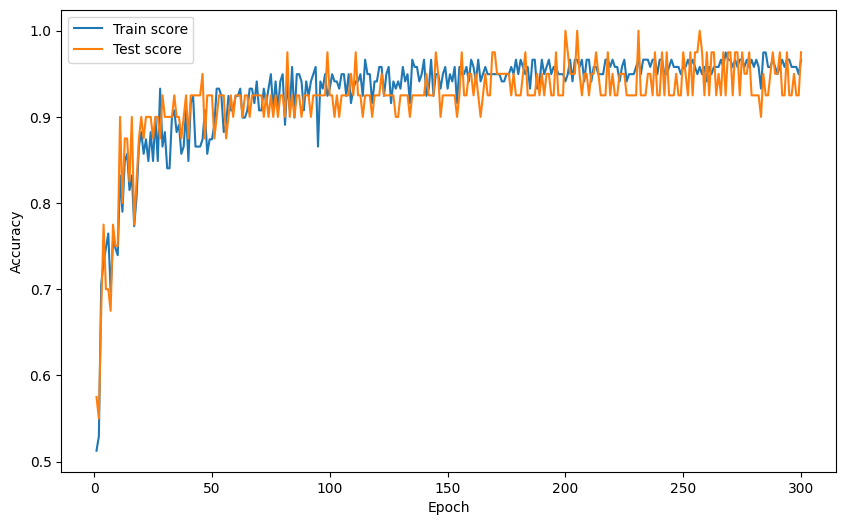

In [47]:
plt.figure(figsize=(10,6))

plt.plot(range(1,301), train_score, label='Train score')
plt.plot(range(1,301), test_score, label='Test score')

plt.xlabel('Epoch')
plt.ylabel('Accuracy')

plt.legend()

plt.show()

In [48]:
sgd_best = SGDClassifier(
    loss='hinge',
    max_iter=100,
    random_state=42
)

sgd_best.fit(train_scaled, train_target)

print("Best Epoch Train score :", sgd_best.score(train_scaled, train_target))
print("Best Epoch Test score  :", sgd_best.score(test_scaled, test_target))

Best Epoch Train score : 0.907563025210084
Best Epoch Test score  : 0.925


In [49]:
print("Epoch 10 모델보다 적절한 epoch 모델의 테스트 정확도가 더 높다.")

Epoch 10 모델보다 적절한 epoch 모델의 테스트 정확도가 더 높다.


In [50]:
print("Epoch가 너무 커지면 과적합이 발생할 수 있으므로 적절한 epoch 선택이 중요하다.")

Epoch가 너무 커지면 과적합이 발생할 수 있으므로 적절한 epoch 선택이 중요하다.
